In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score , accuracy_score,f1_score
from sklearn.utils import resample
from scipy.stats import wilcoxon
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
FEATURE_NAMES = (
    ['n_C','n_N','n_O','n_S','n_F','n_Cl','n_Br','n_I','n_P'] +
    ['n_double','n_triple','n_aromatic','n_rings','n_branches','n_charged'] +
    ['mol_weight','logP_proxy','HBD','HBA','ro5_passed'] +
    ['ro5_mw','ro5_logp','ro5_hbd','ro5_hba'] +
    ['smiles_len','unique_atoms','frac_aromatic'] +
    [f'bigram_{i}' for i in range(27)]   # <-- 27 not 28
)

In [4]:
# Load from the CSV you just exported
df_loaded = pd.read_csv("feature_matrix.csv")

X = df_loaded[FEATURE_NAMES].values      # (2035, 54)
y = df_loaded['BBB_label'].values        # (2035,)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"BBB+    : {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")
print(f"BBB-    : {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"Class prior pi = {(y==1).mean():.4f}")

X shape : (2035, 54)
y shape : (2035,)
BBB+    : 1559  (76.6%)
BBB-    : 476  (23.4%)
Class prior pi = 0.7661


In [5]:
# Split ONCE — this test set never changes across the entire simulation
X_train_pool, X_test_fixed, y_train_pool, y_test_fixed = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"\nTraining pool : {X_train_pool.shape[0]} molecules")
print(f"Fixed test set: {X_test_fixed.shape[0]} molecules")
print(f"Test BBB+     : {(y_test_fixed==1).sum()}  ({(y_test_fixed==1).mean()*100:.1f}%)")
print(f"Test BBB-     : {(y_test_fixed==0).sum()}  ({(y_test_fixed==0).mean()*100:.1f}%)")

# Class index partition from training pool only
idx_pos = np.where(y_train_pool == 1)[0]
idx_neg = np.where(y_train_pool == 0)[0]
pi      = len(idx_pos) / len(y_train_pool)

print(f"\nTraining pool BBB+ indices: {len(idx_pos)}")
print(f"Training pool BBB- indices: {len(idx_neg)}")
print(f"Class prior pi             : {pi:.4f}")


Training pool : 1628 molecules
Fixed test set: 407 molecules
Test BBB+     : 312  (76.7%)
Test BBB-     : 95  (23.3%)

Training pool BBB+ indices: 1247
Training pool BBB- indices: 381
Class prior pi             : 0.7660


In [6]:
def make_classifiers():
    """
    Returns fresh classifier instances per replication.
    LR: L2-regularised (Ridge), C selected to be stable at small n.
    DRF: Random Forest with OOB enabled for internal monitoring.
    """
    lr = LogisticRegression(
        penalty='l2',
        C=1.0,                    # tune if needed via cross-val
        solver='lbfgs',
        max_iter=1000,
        random_state=None         # deterministic given data
    )
    drf = RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        oob_score=True,
        n_jobs=-1,
        random_state=None         # varies per replication intentionally
    )
    return lr, drf

In [7]:
SAMPLE_SIZES = [49, 100, 200, 500, 1000, len(y_train_pool)]
B            = 1000

# Storage
results = {
    n: {
        'LR': [],
        'DRF': [],
        'delta': [],
        'acc_lr': [],
        'acc_drf': [],
        'f1_lr': [],
        'f1_drf': []
    }
    for n in SAMPLE_SIZES
}


print("Starting simulation...\n")
print(f"{'n':>6}  {'Rep':>5}  {'AUC_LR':>8}  {'AUC_DRF':>9}  {'Delta':>8}")
print("-" * 50)

for n in SAMPLE_SIZES:

    # Class-proportional subsample sizes from training pool
    n_pos = round(n * pi)
    n_neg = n - n_pos

    for b in range(B):

        # ── STEP 1: Stratified bootstrap from training pool ONLY ──
        boot_pos = resample(idx_pos, n_samples=n_pos,
                            replace=True, random_state=b)
        boot_neg = resample(idx_neg, n_samples=n_neg,
                            replace=True, random_state=b + 100000)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        X_boot = X_train_pool[boot_idx]
        y_boot = y_train_pool[boot_idx]

        # ── STEP 2: Fit both classifiers on bootstrap sample ──────
        lr, drf = make_classifiers()
        lr.fit(X_boot, y_boot)
        drf.fit(X_boot, y_boot)

        # ── STEP 3: Evaluate on FIXED test set (never changes) ────
        # Probabilities
        proba_lr  = lr.predict_proba(X_test_fixed)[:, 1]
        proba_drf = drf.predict_proba(X_test_fixed)[:, 1]

        # Binary predictions (threshold = 0.5)
        pred_lr  = (proba_lr >= 0.5).astype(int)
        pred_drf = (proba_drf >= 0.5).astype(int)

        # ── AUC ──
        auc_lr  = roc_auc_score(y_test_fixed, proba_lr)
        auc_drf = roc_auc_score(y_test_fixed, proba_drf)

        # ── Accuracy ──
        acc_lr  = accuracy_score(y_test_fixed, pred_lr)
        acc_drf = accuracy_score(y_test_fixed, pred_drf)

        # ── F1-score ──
        f1_lr  = f1_score(y_test_fixed, pred_lr)
        f1_drf = f1_score(y_test_fixed, pred_drf)

        results[n]['LR'].append(auc_lr)
        results[n]['DRF'].append(auc_drf)
        results[n]['delta'].append(auc_drf - auc_lr)
        results[n]['acc_lr'].append(acc_lr)
        results[n]['acc_drf'].append(acc_drf)
        results[n]['f1_lr'].append(f1_lr)
        results[n]['f1_drf'].append(f1_drf)

    # Print progress every 100 reps (last rep shown)
        if (b + 1) % 100 == 0 or b == B - 1:
            print(
                f"  n={n:>5}  b={b+1:>4}  "
                f"AUC_LR={np.mean(results[n]['LR']):.4f}  "
                f"AUC_DRF={np.mean(results[n]['DRF']):.4f}  "
                f"Δ={np.mean(results[n]['delta']):+.4f}  |  "
                f"ACC_LR={np.mean(results[n]['acc_lr']):.4f}  "
                f"ACC_DRF={np.mean(results[n]['acc_drf']):.4f}  |  "
                f"F1_LR={np.mean(results[n]['f1_lr']):.4f}  "
                f"F1_DRF={np.mean(results[n]['f1_drf']):.4f}"
            )


Starting simulation...

     n    Rep    AUC_LR    AUC_DRF     Delta
--------------------------------------------------
  n=   49  b= 100  AUC_LR=0.8693  AUC_DRF=0.9058  Δ=+0.0365  |  ACC_LR=0.8396  ACC_DRF=0.8575  |  F1_LR=0.8968  F1_DRF=0.9121
  n=   49  b= 200  AUC_LR=0.8699  AUC_DRF=0.9040  Δ=+0.0341  |  ACC_LR=0.8411  ACC_DRF=0.8585  |  F1_LR=0.8980  F1_DRF=0.9128
  n=   49  b= 300  AUC_LR=0.8721  AUC_DRF=0.9041  Δ=+0.0320  |  ACC_LR=0.8429  ACC_DRF=0.8591  |  F1_LR=0.8992  F1_DRF=0.9131
  n=   49  b= 400  AUC_LR=0.8712  AUC_DRF=0.9028  Δ=+0.0316  |  ACC_LR=0.8409  ACC_DRF=0.8576  |  F1_LR=0.8978  F1_DRF=0.9122
  n=   49  b= 500  AUC_LR=0.8729  AUC_DRF=0.9031  Δ=+0.0302  |  ACC_LR=0.8421  ACC_DRF=0.8581  |  F1_LR=0.8986  F1_DRF=0.9126
  n=   49  b= 600  AUC_LR=0.8726  AUC_DRF=0.9029  Δ=+0.0303  |  ACC_LR=0.8423  ACC_DRF=0.8581  |  F1_LR=0.8987  F1_DRF=0.9127
  n=   49  b= 700  AUC_LR=0.8736  AUC_DRF=0.9031  Δ=+0.0295  |  ACC_LR=0.8426  ACC_DRF=0.8584  |  F1_LR=0.8989  F1_DRF=0.912

In [8]:
import pandas as pd

rows = []

for n in SAMPLE_SIZES:
    for i in range(len(results[n]['LR'])):
        rows.append({
            'n': n,
            'rep': i + 1,
            'AUC_LR': results[n]['LR'][i],
            'AUC_DRF': results[n]['DRF'][i],
            'delta': results[n]['delta'][i],
            'ACC_LR': results[n]['acc_lr'][i],
            'ACC_DRF': results[n]['acc_drf'][i],
            'F1_LR': results[n]['f1_lr'][i],
            'F1_DRF': results[n]['f1_drf'][i]
        })

df_all = pd.DataFrame(rows)

# Save to CSV
df_all.to_csv("simulation_full_results.csv", index=False)

print("Saved to simulation_full_results.csv")


Saved to simulation_full_results.csv


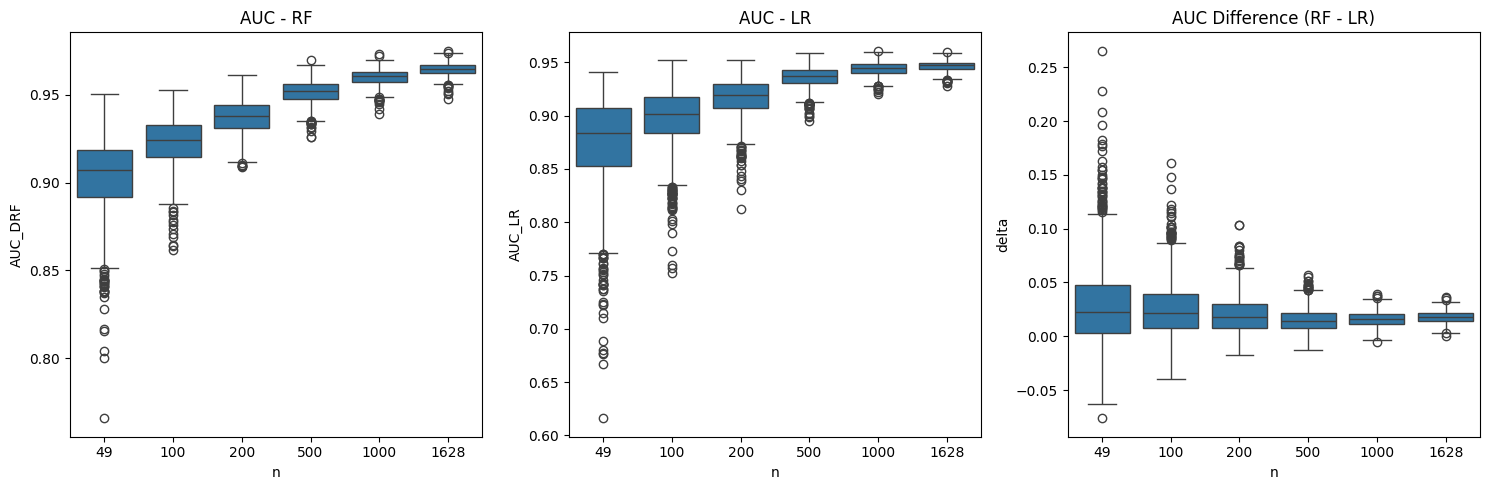

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# AUC DRF
sns.boxplot(data=df_all, x='n', y='AUC_DRF', ax=axes[0])
axes[0].set_title("AUC - RF")

# AUC LR
sns.boxplot(data=df_all, x='n', y='AUC_LR', ax=axes[1])
axes[1].set_title("AUC - LR")

# Delta
sns.boxplot(data=df_all, x='n', y='delta', ax=axes[2])
axes[2].set_title("AUC Difference (RF - LR)")

plt.tight_layout()
plt.show()


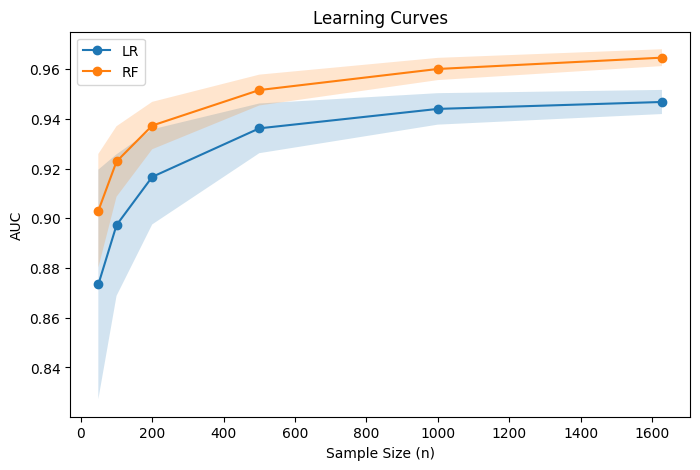

In [20]:
import matplotlib.pyplot as plt

mean_auc = df_all.groupby('n')[['AUC_LR','AUC_DRF']].mean()
std_auc  = df_all.groupby('n')[['AUC_LR','AUC_DRF']].std()

plt.figure(figsize=(8,5))

plt.plot(mean_auc.index, mean_auc['AUC_LR'], marker='o', label='LR')
plt.plot(mean_auc.index, mean_auc['AUC_DRF'], marker='o', label='RF')

plt.fill_between(mean_auc.index,
                 mean_auc['AUC_LR'] - std_auc['AUC_LR'],
                 mean_auc['AUC_LR'] + std_auc['AUC_LR'],
                 alpha=0.2)

plt.fill_between(mean_auc.index,
                 mean_auc['AUC_DRF'] - std_auc['AUC_DRF'],
                 mean_auc['AUC_DRF'] + std_auc['AUC_DRF'],
                 alpha=0.2)

plt.xlabel("Sample Size (n)")
plt.ylabel("AUC")
plt.title("Learning Curves")
plt.legend()
plt.show()


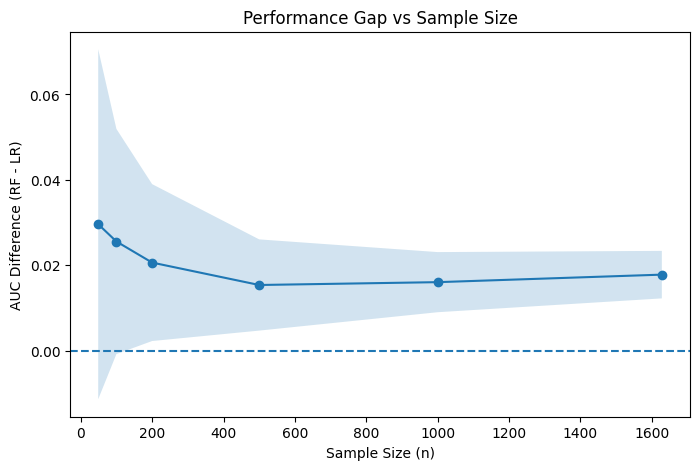

In [21]:
mean_delta = df_all.groupby('n')['delta'].mean()
std_delta  = df_all.groupby('n')['delta'].std()

plt.figure(figsize=(8,5))
plt.plot(mean_delta.index, mean_delta.values, marker='o')

plt.fill_between(mean_delta.index,
                 mean_delta - std_delta,
                 mean_delta + std_delta,
                 alpha=0.2)

plt.axhline(0, linestyle='--')

plt.xlabel("Sample Size (n)")
plt.ylabel("AUC Difference (RF - LR)")
plt.title("Performance Gap vs Sample Size")
plt.show()


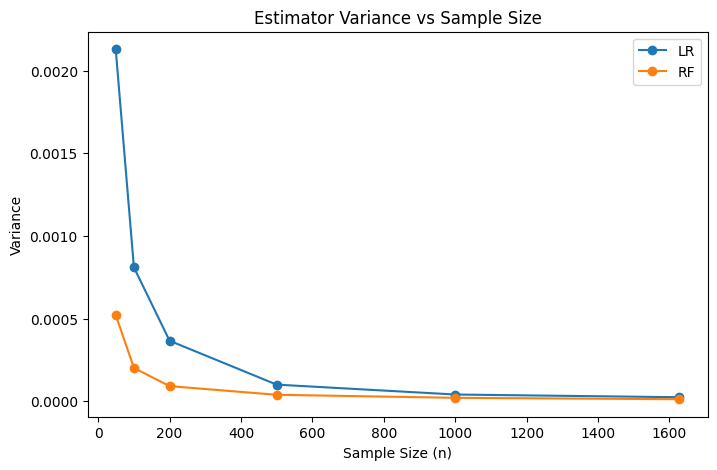

In [22]:
var_auc = df_all.groupby('n')[['AUC_LR','AUC_DRF']].var()

plt.figure(figsize=(8,5))
plt.plot(var_auc.index, var_auc['AUC_LR'], marker='o', label='LR')
plt.plot(var_auc.index, var_auc['AUC_DRF'], marker='o', label='RF')

plt.xlabel("Sample Size (n)")
plt.ylabel("Variance")
plt.title("Estimator Variance vs Sample Size")
plt.legend()
plt.show()


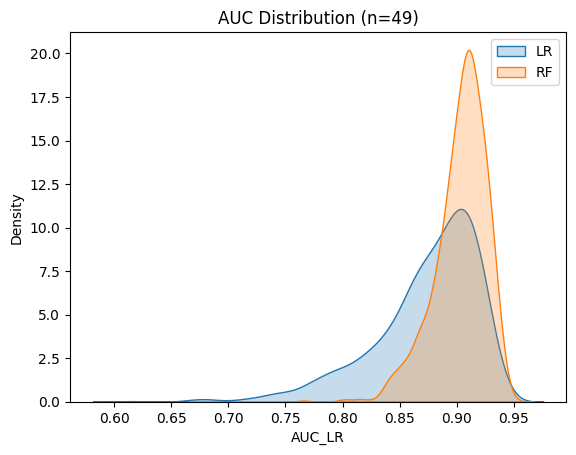

In [23]:
import seaborn as sns

subset = df_all[df_all['n'] == 49]

sns.kdeplot(subset['AUC_LR'], label='LR', fill=True)
sns.kdeplot(subset['AUC_DRF'], label='RF', fill=True)

plt.title("AUC Distribution (n=49)")
plt.legend()
plt.show()


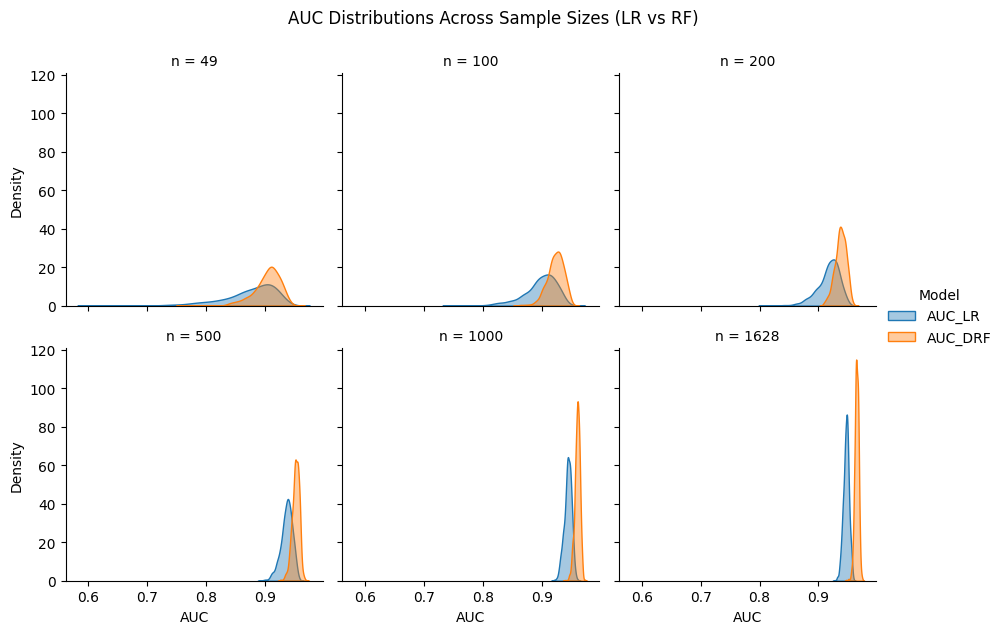

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_melt = df_all.melt(
    id_vars=['n'],
    value_vars=['AUC_LR', 'AUC_DRF'],
    var_name='Model',
    value_name='AUC'
)

g = sns.FacetGrid(
    df_melt,
    col="n",
    hue="Model",          
    col_wrap=3,
    height=3,
    sharex=True,
    sharey=True
)

g.map(sns.kdeplot, "AUC", fill=True, alpha=0.4)
g.add_legend()

g.set_titles("n = {col_name}")
g.fig.suptitle("AUC Distributions Across Sample Sizes (LR vs RF)", y=1.05)

plt.show()


In [13]:
summary_rows = []

for n in SAMPLE_SIZES:

    auc_lr  = np.array(results[n]['LR'])
    auc_drf = np.array(results[n]['DRF'])
    delta   = np.array(results[n]['delta'])
    acc_lr  = np.array(results[n]['acc_lr'])
    acc_drf = np.array(results[n]['acc_drf'])

    f1_lr  = np.array(results[n]['f1_lr'])
    f1_drf = np.array(results[n]['f1_drf'])


    # Wilcoxon signed-rank test on paired differences
    # zero_method='wilcox' drops exact zeros before ranking
    stat, p_val = wilcoxon(delta, zero_method='wilcox')

    re_n = np.var(auc_drf) / np.var(auc_lr)   # relative efficiency

    summary_rows.append({
        'n'              : n,

        # ── AUC ──
        'mean_AUC_LR'    : np.mean(auc_lr),
        'mean_AUC_DRF'   : np.mean(auc_drf),
        'var_LR'         : np.var(auc_lr),
        'var_DRF'        : np.var(auc_drf),
        'CI_LR_low'      : np.percentile(auc_lr, 2.5),
        'CI_LR_high'     : np.percentile(auc_lr, 97.5),
        'CI_DRF_low'     : np.percentile(auc_drf, 2.5),
        'CI_DRF_high'    : np.percentile(auc_drf, 97.5),

        # ── Accuracy ──
        'mean_ACC_LR'    : np.mean(acc_lr),
        'mean_ACC_DRF'   : np.mean(acc_drf),
        'var_ACC_LR'     : np.var(acc_lr),
        'var_ACC_DRF'    : np.var(acc_drf),

        # ── F1 ──
        'mean_F1_LR'     : np.mean(f1_lr),
        'mean_F1_DRF'    : np.mean(f1_drf),
        'var_F1_LR'      : np.var(f1_lr),
        'var_F1_DRF'     : np.var(f1_drf),

        # ── Comparison ──
        'median_delta'   : np.median(delta),
        'RE_n'           : re_n,
        'wilcoxon_stat'  : stat,
        'p_value'        : p_val,
        'sig_DRF_wins'   : (p_val < 0.05) and (np.median(delta) > 0)
})


df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv("simulation_summary.csv", index=False)

# Print clean table
print(df_summary[[
    'n',
    'mean_AUC_LR','mean_AUC_DRF',
    'mean_ACC_LR','mean_ACC_DRF',
    'mean_F1_LR','mean_F1_DRF',
    'RE_n','median_delta','p_value','sig_DRF_wins'
]].to_string(index=False, float_format=lambda x: f"{x:.5f}"))

   n  mean_AUC_LR  mean_AUC_DRF  mean_ACC_LR  mean_ACC_DRF  mean_F1_LR  mean_F1_DRF    RE_n  median_delta  p_value  sig_DRF_wins
  49      0.87340       0.90301      0.84234       0.85800     0.89874      0.91266 0.24490       0.02296  0.00000          True
 100      0.89726       0.92283      0.85564       0.87714     0.90720      0.92334 0.24817       0.02136  0.00000          True
 200      0.91664       0.93728      0.86807       0.88948     0.91521      0.93036 0.24852       0.01830  0.00000          True
 500      0.93616       0.95155      0.88034       0.90121     0.92321      0.93733 0.38464       0.01452  0.00000          True
1000      0.94397       0.96003      0.88527       0.90902     0.92645      0.94209 0.49939       0.01600  0.00000          True
1628      0.94676       0.96458      0.88643       0.91377     0.92725      0.94500 0.48913       0.01776  0.00000          True


In [9]:
# n* = smallest n where DRF significantly beats LR
crossover = df_summary[df_summary['sig_DRF_wins'] == True]

if len(crossover) > 0:
    n_star = crossover['n'].iloc[0]
    print(f"\nCrossover point n* = {n_star}")
    print(f"At n={n_star}: mean AUC LR={crossover['mean_AUC_LR'].iloc[0]:.4f}, "
          f"DRF={crossover['mean_AUC_DRF'].iloc[0]:.4f}, "
          f"p={crossover['p_value'].iloc[0]:.4f}")
else:
    print("\nNo significant crossover found across tested sample sizes.")
    print("DRF does not significantly outperform LR at any tested n.")


Crossover point n* = 49
At n=49: mean AUC LR=0.8734, DRF=0.9030, p=0.0000
